# 02 — Data Cleaning & Merging

In [3]:
#Imports
import pandas as pd
import numpy as np
import os

In [1]:
import os

#setting working directory as Github for this project
os.chdir('/Users/charlottewest/Documents/QSS20-CW-Final')

# Confirm it worked
print(os.getcwd())
print(os.listdir('data'))

/Users/charlottewest/Documents/QSS20-CW-Final
['nj_zcta_2024.geojson', 'zipcodes_raw.csv', 'README.md', 'census_raw.csv', 'ucmr5_nj_slim.csv']


## Loading Raw Data
Loading the raw files saved by `01_data_pull.ipynb` from the `data/` folder.

In [4]:
# Load UCMR5 occurrence data 


ucmr_nj = pd.read_csv('data/ucmr5_nj_slim.csv')


ucmr_nj.head()

,PWSID,PWSName,State,Size,FacilityWaterType,Contaminant,AnalyticalResultValue,AnalyticalResultsSign,MRL,Units,CollectionDate,Region
0,NJ0102001,ATLANTIC CITY MUA,NJ,L,SW,PFUnA,NaN,<,0.002,µg/L,7/9/2024,2
1,NJ0102001,ATLANTIC CITY MUA,NJ,L,SW,ADONA,NaN,<,0.003,µg/L,7/9/2024,2
2,NJ0102001,ATLANTIC CITY MUA,NJ,L,SW,9Cl-PF3ONS,NaN,<,0.002,µg/L,7/9/2024,2
3,NJ0102001,ATLANTIC CITY MUA,NJ,L,SW,PFHpS,NaN,<,0.003,µg/L,7/9/2024,2
4,NJ0102001,ATLANTIC CITY MUA,NJ,L,SW,PFPeS,NaN,<,0.004,µg/L,7/9/2024,2


In [9]:
#Load ZIP codes data
nj_zc = pd.read_csv(
    'data/zipcodes_raw.csv',
    dtype={'PWSID': str, 'ZIPCode': str}
)

nj_zc.head()

,PWSID,ZIPCODE
0,010106001,6338
1,010109005,6382
2,020000005,13655
3,020000008,14070
4,020000008,14081


In [6]:
#Load Census data
census_df = pd.read_csv(
    'data/census_raw.csv',
    dtype={'GEO_ID': str}
)

print(f'Census rows loaded: {len(census_df)}')
census_df.head()

Census rows loaded: 599


,GEO_ID,NAME,DP05_0001E,DP05_0001M,DP05_0002E,DP05_0002M,DP05_0003E,DP05_0003M,DP05_0004E,DP05_0004M,...,DP05_0104PM,DP05_0105PE,DP05_0105PM,DP05_0106PE,DP05_0106PM,DP05_0107PE,DP05_0107PM,DP05_0108PE,DP05_0108PM,Unnamed: 434
0,0400000US34,New Jersey,9343809,*****,4598393,534,4745416,534,96.9,0.1,...,0.1,(X),(X),6433714,(X),48.3,0.1,51.7,0.1,NaN
1,860Z200US07001,ZCTA5 07001,17121,1128,9860,747,7261,666,135.8,13.9,...,1.6,(X),(X),11991,(X),58.7,3.0,41.3,3.0,NaN
2,860Z200US07002,ZCTA5 07002,71553,58,35678,818,35875,816,99.5,4.5,...,0.8,(X),(X),47852,(X),48.5,1.4,51.5,1.4,NaN
3,860Z200US07003,ZCTA5 07003,53771,44,26660,617,27111,621,98.3,4.5,...,0.6,(X),(X),38709,(X),48.7,1.4,51.3,1.4,NaN
4,860Z200US07004,ZCTA5 07004,7824,317,3373,365,4451,339,75.8,12.6,...,0.9,(X),(X),5907,(X),44.3,5.0,55.7,5.0,NaN


## Fixing Zipcodes and merging

In [10]:
#Merge UCMR5 occurrence data with zip codes
merged_ucmr_zc = ucmr_nj.merge(nj_zc, on='PWSID', how='left').copy()

print(f"Rows before join: {len(ucmr_nj)}")
print(f"Rows after join: {len(merged_ucmr_zc)}")
print(merged_ucmr_zc.head())

Rows before join: 56542
Rows after join: 263125
       PWSID            PWSName State Size FacilityWaterType Contaminant  \
0  NJ0102001  ATLANTIC CITY MUA    NJ    L                SW       PFUnA   
1  NJ0102001  ATLANTIC CITY MUA    NJ    L                SW       ADONA   
2  NJ0102001  ATLANTIC CITY MUA    NJ    L                SW  9Cl-PF3ONS   
3  NJ0102001  ATLANTIC CITY MUA    NJ    L                SW       PFHpS   
4  NJ0102001  ATLANTIC CITY MUA    NJ    L                SW       PFPeS   

   AnalyticalResultValue AnalyticalResultsSign    MRL Units CollectionDate  \
0                    NaN                     <  0.002  µg/L       7/9/2024   
1                    NaN                     <  0.003  µg/L       7/9/2024   
2                    NaN                     <  0.002  µg/L       7/9/2024   
3                    NaN                     <  0.003  µg/L       7/9/2024   
4                    NaN                     <  0.004  µg/L       7/9/2024   

   Region  ZIPCODE  
0    

In [11]:
print(merged_ucmr_zc["Contaminant"].unique())

['PFUnA' 'ADONA' '9Cl-PF3ONS' 'PFHpS' 'PFPeS' 'NFDHA' 'PFEESA' 'PFMBA'
 'PFPeA' 'PFMPA' '8:2 FTS' '4:2 FTS' '6:2 FTS' 'HFPO-DA' '11Cl-PF3OUdS'
 'PFTrDA' 'PFHxA' 'PFDoA' 'PFDA' 'PFOA' 'PFOS' 'PFNA' 'PFHxS' 'PFHpA'
 'PFBS' 'lithium' 'NMeFOSAA' 'NEtFOSAA' 'PFTA' 'PFBA']


In [12]:
#checking to see how many NaN values there are
print(merged_ucmr_zc["AnalyticalResultValue"].isna())

0         True
1         True
2         True
3         True
4         True
          ... 
263120    True
263121    True
263122    True
263123    True
263124    True
Name: AnalyticalResultValue, Length: 263125, dtype: bool


In [13]:
merged_ucmr_zc['AnalyticalResultValue'] = merged_ucmr_zc['AnalyticalResultValue'].fillna(0)

In [14]:
# Keep only PFAS (all start with "PF" or are HFPO-DA)
pfas_df = merged_ucmr_zc[
    merged_ucmr_zc['Contaminant'].str.startswith('PF') | 
    merged_ucmr_zc['Contaminant'].str.contains('HFPO-DA')
]

print(pfas_df['Contaminant'].unique())

['PFUnA' 'PFHpS' 'PFPeS' 'PFEESA' 'PFMBA' 'PFPeA' 'PFMPA' 'HFPO-DA'
 'PFTrDA' 'PFHxA' 'PFDoA' 'PFDA' 'PFOA' 'PFOS' 'PFNA' 'PFHxS' 'PFHpA'
 'PFBS' 'PFTA' 'PFBA']


In [15]:
#now I have to aggregate so its only one row for each zipcode... yay

zip_pfas = pfas_df.groupby('ZIPCODE').agg(
    max_pfas    = ('AnalyticalResultValue', 'max'),   # highest single PFAS reading
    mean_pfas   = ('AnalyticalResultValue', 'mean'),  # average across all PFAS
    total_detections = ('AnalyticalResultValue', lambda x: (x > 0).sum()),  # count of detections
    num_contaminants = ('Contaminant', 'nunique')     # how many different PFAS detected
).reset_index()

print(zip_pfas.head(10))

   ZIPCODE  max_pfas  mean_pfas  total_detections  num_contaminants
0     7002    0.0046   0.000164                 3                20
1     7003    0.0053   0.000080                 4                20
2     7004    0.0115   0.001414                17                20
3     7005    0.0111   0.000962                36                20
4     7006    0.0423   0.001141                69                20
5     7008    0.0073   0.000251                11                20
6     7009    0.0423   0.000506                15                20
7     7010    0.0140   0.001138                48                20
8     7011    0.0119   0.001979                23                20
9     7012    0.0119   0.001979                23                20


## now since the data looks so clean and fancy, we can use the census data for NJ

In [18]:
#shortening GEO_ID so its just the Zipcode given
census_df['ZIPCODE'] = census_df['GEO_ID'].str[-5:]
census_df

,GEO_ID,NAME,DP05_0001E,DP05_0001M,DP05_0002E,DP05_0002M,DP05_0003E,DP05_0003M,DP05_0004E,DP05_0004M,...,DP05_0105PE,DP05_0105PM,DP05_0106PE,DP05_0106PM,DP05_0107PE,DP05_0107PM,DP05_0108PE,DP05_0108PM,Unnamed: 434,ZIPCODE
0,0400000US34,New Jersey,9343809,*****,4598393,534,4745416,534,96.9,0.1,...,(X),(X),6433714,(X),48.3,0.1,51.7,0.1,NaN,0US34
1,860Z200US07001,ZCTA5 07001,17121,1128,9860,747,7261,666,135.8,13.9,...,(X),(X),11991,(X),58.7,3.0,41.3,3.0,NaN,07001
2,860Z200US07002,ZCTA5 07002,71553,58,35678,818,35875,816,99.5,4.5,...,(X),(X),47852,(X),48.5,1.4,51.5,1.4,NaN,07002
3,860Z200US07003,ZCTA5 07003,53771,44,26660,617,27111,621,98.3,4.5,...,(X),(X),38709,(X),48.7,1.4,51.3,1.4,NaN,07003
4,860Z200US07004,ZCTA5 07004,7824,317,3373,365,4451,339,75.8,12.6,...,(X),(X),5907,(X),44.3,5.0,55.7,5.0,NaN,07004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,860Z200US08889,ZCTA5 08889,10193,627,5177,444,5016,381,103.2,10.9,...,(X),(X),8351,(X),49.1,2.8,50.9,2.8,NaN,08889
595,860Z200US08890,ZCTA5 08890,17,4,17,4,0,14,-,**,...,(X),(X),17,(X),100.0,84.6,0.0,84.6,NaN,08890
596,860Z200US08901,ZCTA5 08901,57263,69,30012,1179,27251,1171,110.1,9.0,...,(X),(X),30157,(X),50.8,2.8,49.2,2.8,NaN,08901
597,860Z200US08902,ZCTA5 08902,43932,377,21558,657,22374,669,96.4,5.6,...,(X),(X),27252,(X),47.9,1.8,52.1,1.8,NaN,08902


In [19]:
#first row is a a little strange and I want to add columns with the data I want renamed so its easier for me to interpret
#using data names from the metadata

formated_census_df = census_df.drop(index=0).reset_index(drop=True)
formated_census_df

,GEO_ID,NAME,DP05_0001E,DP05_0001M,DP05_0002E,DP05_0002M,DP05_0003E,DP05_0003M,DP05_0004E,DP05_0004M,...,DP05_0105PE,DP05_0105PM,DP05_0106PE,DP05_0106PM,DP05_0107PE,DP05_0107PM,DP05_0108PE,DP05_0108PM,Unnamed: 434,ZIPCODE
0,860Z200US07001,ZCTA5 07001,17121,1128,9860,747,7261,666,135.8,13.9,...,(X),(X),11991,(X),58.7,3.0,41.3,3.0,NaN,07001
1,860Z200US07002,ZCTA5 07002,71553,58,35678,818,35875,816,99.5,4.5,...,(X),(X),47852,(X),48.5,1.4,51.5,1.4,NaN,07002
2,860Z200US07003,ZCTA5 07003,53771,44,26660,617,27111,621,98.3,4.5,...,(X),(X),38709,(X),48.7,1.4,51.3,1.4,NaN,07003
3,860Z200US07004,ZCTA5 07004,7824,317,3373,365,4451,339,75.8,12.6,...,(X),(X),5907,(X),44.3,5.0,55.7,5.0,NaN,07004
4,860Z200US07005,ZCTA5 07005,15307,416,8047,461,7260,500,110.8,12.6,...,(X),(X),11348,(X),51.3,2.8,48.7,2.8,NaN,07005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,860Z200US08889,ZCTA5 08889,10193,627,5177,444,5016,381,103.2,10.9,...,(X),(X),8351,(X),49.1,2.8,50.9,2.8,NaN,08889
594,860Z200US08890,ZCTA5 08890,17,4,17,4,0,14,-,**,...,(X),(X),17,(X),100.0,84.6,0.0,84.6,NaN,08890
595,860Z200US08901,ZCTA5 08901,57263,69,30012,1179,27251,1171,110.1,9.0,...,(X),(X),30157,(X),50.8,2.8,49.2,2.8,NaN,08901
596,860Z200US08902,ZCTA5 08902,43932,377,21558,657,22374,669,96.4,5.6,...,(X),(X),27252,(X),47.9,1.8,52.1,1.8,NaN,08902


In [20]:
# Keeping only columns I need
cols_to_keep = [
    'ZIPCODE',
    'NAME',
    'DP05_0033E',   # total population
    'DP05_0083PE',  # % White
    'DP05_0084PE',  # % Black
    'DP05_0085PE',  # % American Indian
    'DP05_0086PE',  # % Asian
    'DP05_0087PE',  # % Native Hawaiian
    'DP05_0090PE',  # % Hispanic or Latino
    'DP05_0096PE',  # % Non-Hispanic White
]
cleaned_census_df = census_clean = census_df[cols_to_keep].copy().drop(index=0).reset_index(drop=True)
cleaned_census_df

,ZIPCODE,NAME,DP05_0033E,DP05_0083PE,DP05_0084PE,DP05_0085PE,DP05_0086PE,DP05_0087PE,DP05_0090PE,DP05_0096PE
0,07001,ZCTA5 07001,17121,45.1,34.4,1.4,17.0,0.0,25.3,27.9
1,07002,ZCTA5 07002,71553,65.5,17.3,1.5,10.2,0.1,32.1,42.5
2,07003,ZCTA5 07003,53771,56.5,20.1,1.7,11.0,0.0,30.9,37.4
3,07004,ZCTA5 07004,7824,94.7,1.8,0.2,4.2,0.2,11.7,82.2
4,07005,ZCTA5 07005,15307,86.6,5.3,1.5,8.7,0.2,11.6,74.1
...,...,...,...,...,...,...,...,...,...,...
593,08889,ZCTA5 08889,10193,90.4,1.4,0.3,8.2,0.0,8.9,79.2
594,08890,ZCTA5 08890,17,0.0,47.1,0.0,52.9,0.0,0.0,0.0
595,08901,ZCTA5 08901,57263,37.6,15.2,10.7,9.1,0.1,53.9,23.6
596,08902,ZCTA5 08902,43932,35.8,23.9,0.8,23.3,0.1,29.0,25.7


In [21]:
#all column names taken from the metadata associated with the data
rename_dict = {
    'DP05_0033E'  : 'total_pop',
    'DP05_0083PE' : 'pct_white',
    'DP05_0084PE' : 'pct_black',
    'DP05_0085PE' : 'pct_native',
    'DP05_0086PE' : 'pct_asian',
    'DP05_0087PE' : 'pct_pacific_islander',
    'DP05_0090PE' : 'pct_hispanic',
    'DP05_0096PE' : 'pct_nonhispanic_white'
}

# Apply it
cleaned_census_df = cleaned_census_df.rename(columns=rename_dict)

# Check it worked
print(cleaned_census_df.columns.tolist())
print(cleaned_census_df.head())

['ZIPCODE', 'NAME', 'total_pop', 'pct_white', 'pct_black', 'pct_native', 'pct_asian', 'pct_pacific_islander', 'pct_hispanic', 'pct_nonhispanic_white']
  ZIPCODE         NAME  total_pop pct_white pct_black pct_native pct_asian  \
0   07001  ZCTA5 07001      17121      45.1      34.4        1.4      17.0   
1   07002  ZCTA5 07002      71553      65.5      17.3        1.5      10.2   
2   07003  ZCTA5 07003      53771      56.5      20.1        1.7      11.0   
3   07004  ZCTA5 07004       7824      94.7       1.8        0.2       4.2   
4   07005  ZCTA5 07005      15307      86.6       5.3        1.5       8.7   

  pct_pacific_islander pct_hispanic pct_nonhispanic_white  
0                  0.0         25.3                  27.9  
1                  0.1         32.1                  42.5  
2                  0.0         30.9                  37.4  
3                  0.2         11.7                  82.2  
4                  0.2         11.6                  74.1  


In [22]:
#adding a column for pct minority.
cleaned_census_df['pct_nonhispanic_white'] = pd.to_numeric(
    cleaned_census_df['pct_nonhispanic_white'], errors='coerce'
)

cleaned_census_df['pct_minority'] = 100 - cleaned_census_df['pct_nonhispanic_white']

# Check it looks right
print(cleaned_census_df[['ZIPCODE', 'pct_nonhispanic_white', 'pct_minority']].head(10))

  ZIPCODE  pct_nonhispanic_white  pct_minority
0   07001                   27.9          72.1
1   07002                   42.5          57.5
2   07003                   37.4          62.6
3   07004                   82.2          17.8
4   07005                   74.1          25.9
5   07006                   72.0          28.0
6   07008                   18.7          81.3
7   07009                   76.1          23.9
8   07010                   41.4          58.6
9   07011                   33.6          66.4


In [31]:
# converting both ZIPCODE columns to strings so that I can merge the two data sets with an inner merge


zip_pfas['ZIPCODE'] = zip_pfas['ZIPCODE'].astype(str).str.zfill(5)
cleaned_census_df['ZIPCODE'] = cleaned_census_df['ZIPCODE'].astype(str).str.zfill(5)

#now making the final dataset
final_race_df = zip_pfas.merge(
    cleaned_census_df,
    left_on  = 'ZIPCODE',   # column name in PFAS data
    right_on = 'ZIPCODE',   # column name in Census data
    how      = 'inner'      # only keep ZIPs that exist in both
)
final_race_df

,ZIPCODE,max_pfas,mean_pfas,total_detections,num_contaminants,NAME,total_pop,pct_white,pct_black,pct_native,pct_asian,pct_pacific_islander,pct_hispanic,pct_nonhispanic_white,pct_minority
0,07002,0.0046,0.000164,3,20,ZCTA5 07002,71553,65.5,17.3,1.5,10.2,0.1,32.1,42.5,57.5
1,07003,0.0053,0.000080,4,20,ZCTA5 07003,53771,56.5,20.1,1.7,11.0,0.0,30.9,37.4,62.6
2,07004,0.0115,0.001414,17,20,ZCTA5 07004,7824,94.7,1.8,0.2,4.2,0.2,11.7,82.2,17.8
3,07005,0.0111,0.000962,36,20,ZCTA5 07005,15307,86.6,5.3,1.5,8.7,0.2,11.6,74.1,25.9
4,07006,0.0423,0.001141,69,20,ZCTA5 07006,26654,84.6,5.2,1.3,11.2,0.2,12.7,72.0,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,08886,0.0000,0.000000,0,20,ZCTA5 08886,6435,81.8,9.1,0.2,10.6,0.4,14.6,67.8,32.2
469,08889,0.0075,0.000254,19,20,ZCTA5 08889,10193,90.4,1.4,0.3,8.2,0.0,8.9,79.2,20.8
470,08901,0.0077,0.000819,14,20,ZCTA5 08901,57263,37.6,15.2,10.7,9.1,0.1,53.9,23.6,76.4
471,08902,0.0000,0.000000,0,20,ZCTA5 08902,43932,35.8,23.9,0.8,23.3,0.1,29.0,25.7,74.3


## Loading NJ Zipcode district shapes

In [24]:


# Load NJ ZIP code boundaries directly from Census Tiger files

import geopandas as gpd

nj_shapefile_slim = gpd.read_file(
    "data/nj_zcta_2024.geojson"
)
print(nj_shapefile_slim.columns.tolist())
print(nj_shapefile_slim['ZIPCODE'])


print(f"NJ ZIP shapes: {len(nj_shapefile_slim)}")
#should be 598 bc 598 counties

['ZIPCODE', 'GEOID20', 'GEOIDFQ20', 'CLASSFP20', 'MTFCC20', 'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20', 'geometry']
0      07066
1      07608
2      08723
3      08088
4      08008
       ...  
593    08518
594    08064
595    08097
596    08722
597    08073
Name: ZIPCODE, Length: 598, dtype: object
NJ ZIP shapes: 598


## Merging PFAS + Census data onto the shapefile

In [32]:

map_df = nj_shapefile_slim.merge(
    final_race_df,
    on   = 'ZIPCODE',
    how  = 'left'
)
#confirming all the data got merged properly
print(f"Rows in map data: {len(map_df)}")

Rows in map data: 598


In [26]:
#converting all values to numbers (besides for Zipcode)

numeric_cols = [
    'max_pfas', 
    'mean_pfas',
    'total_detections',
    'pct_white', 
    'pct_black', 
    'pct_asian',
    'pct_hispanic', 
    'pct_native',
    'pct_nonhispanic_white',
    'total_pop',
    'pct_minority'
]

for col in numeric_cols:
    map_df[col] = pd.to_numeric(map_df[col], errors='coerce')
    

In [33]:
#adding column for max values based on EPA standards
map_df['max_pfas'] = pd.to_numeric(map_df['max_pfas'], errors='coerce') * 1000

# Flag ZIPs that exceed EPA MCL of 4 ng/L
map_df['exceeds_mcl'] = map_df['mean_pfas'] > 4

In [35]:
#saving back to the og data folder to visualize in another notebook
map_df.to_csv('data/final_map.csv', index = False)
final_race_df.to_csv('data/final_clean_race.csv', index=False)

## Now visualizing data

In [27]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

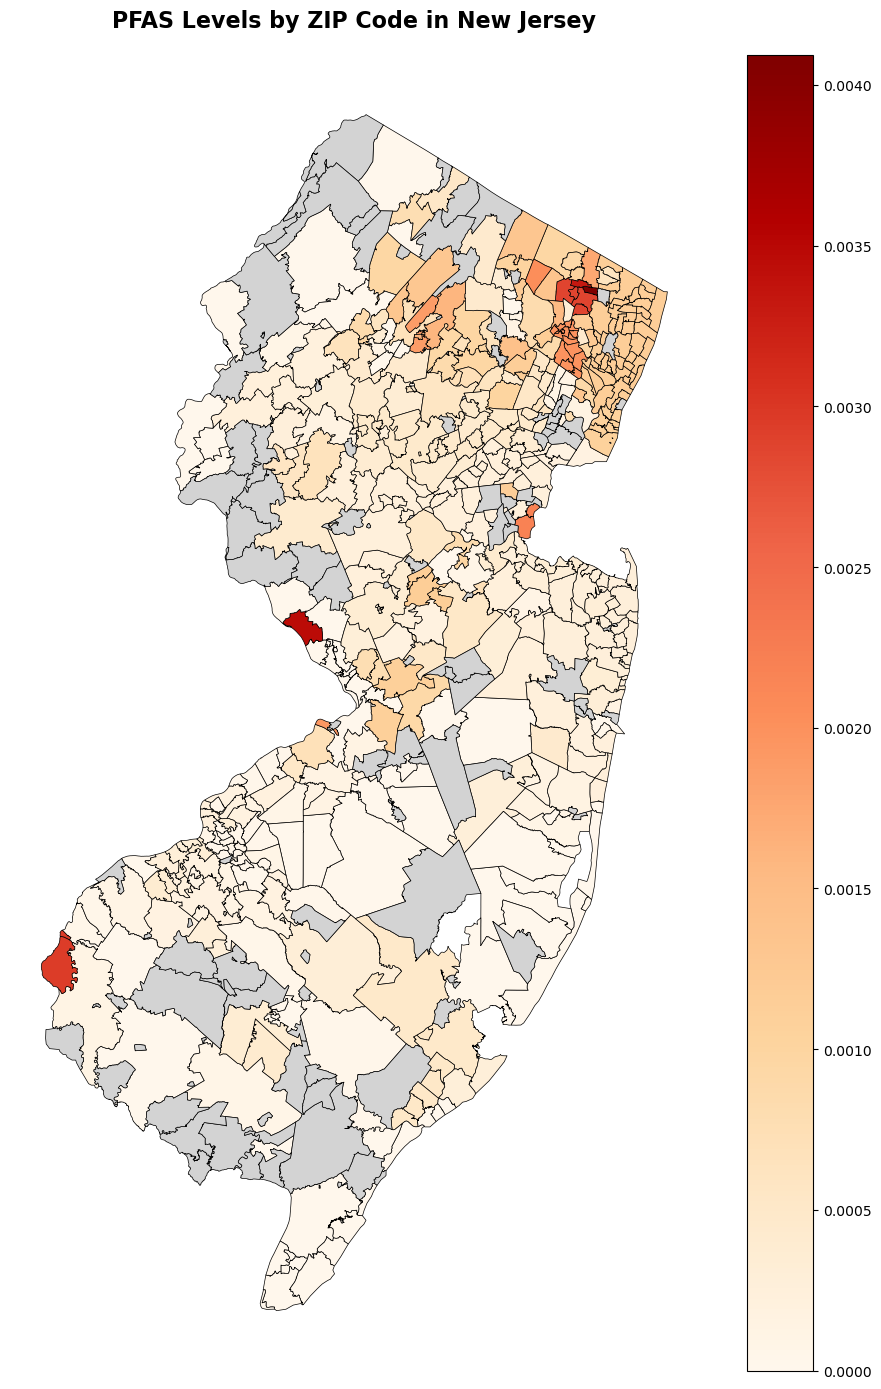

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

#most of this I got from the matplot website help
map_df.plot(
    column    = 'mean_pfas',         # color by mean PFAS concentration
    cmap      = 'OrRd',             # orange to red (higher = darker red)
    linewidth = 0.5,
    edgecolor = 'black',
    legend    = True,
    missing_kwds = {                # style for ZIPs with no PFAS data
        'color'    : 'lightgrey',
        'label'    : 'No Data'
    },
    ax = ax
)

ax.set_title('PFAS Levels by ZIP Code in New Jersey', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('output/nj_pfas_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
#converting to units for limit levels
map_df['mean_pfas'] = pd.to_numeric(map_df['mean_pfas'], errors='coerce') * 1000
map_df['max_pfas'] = pd.to_numeric(map_df['max_pfas'], errors='coerce') * 1000

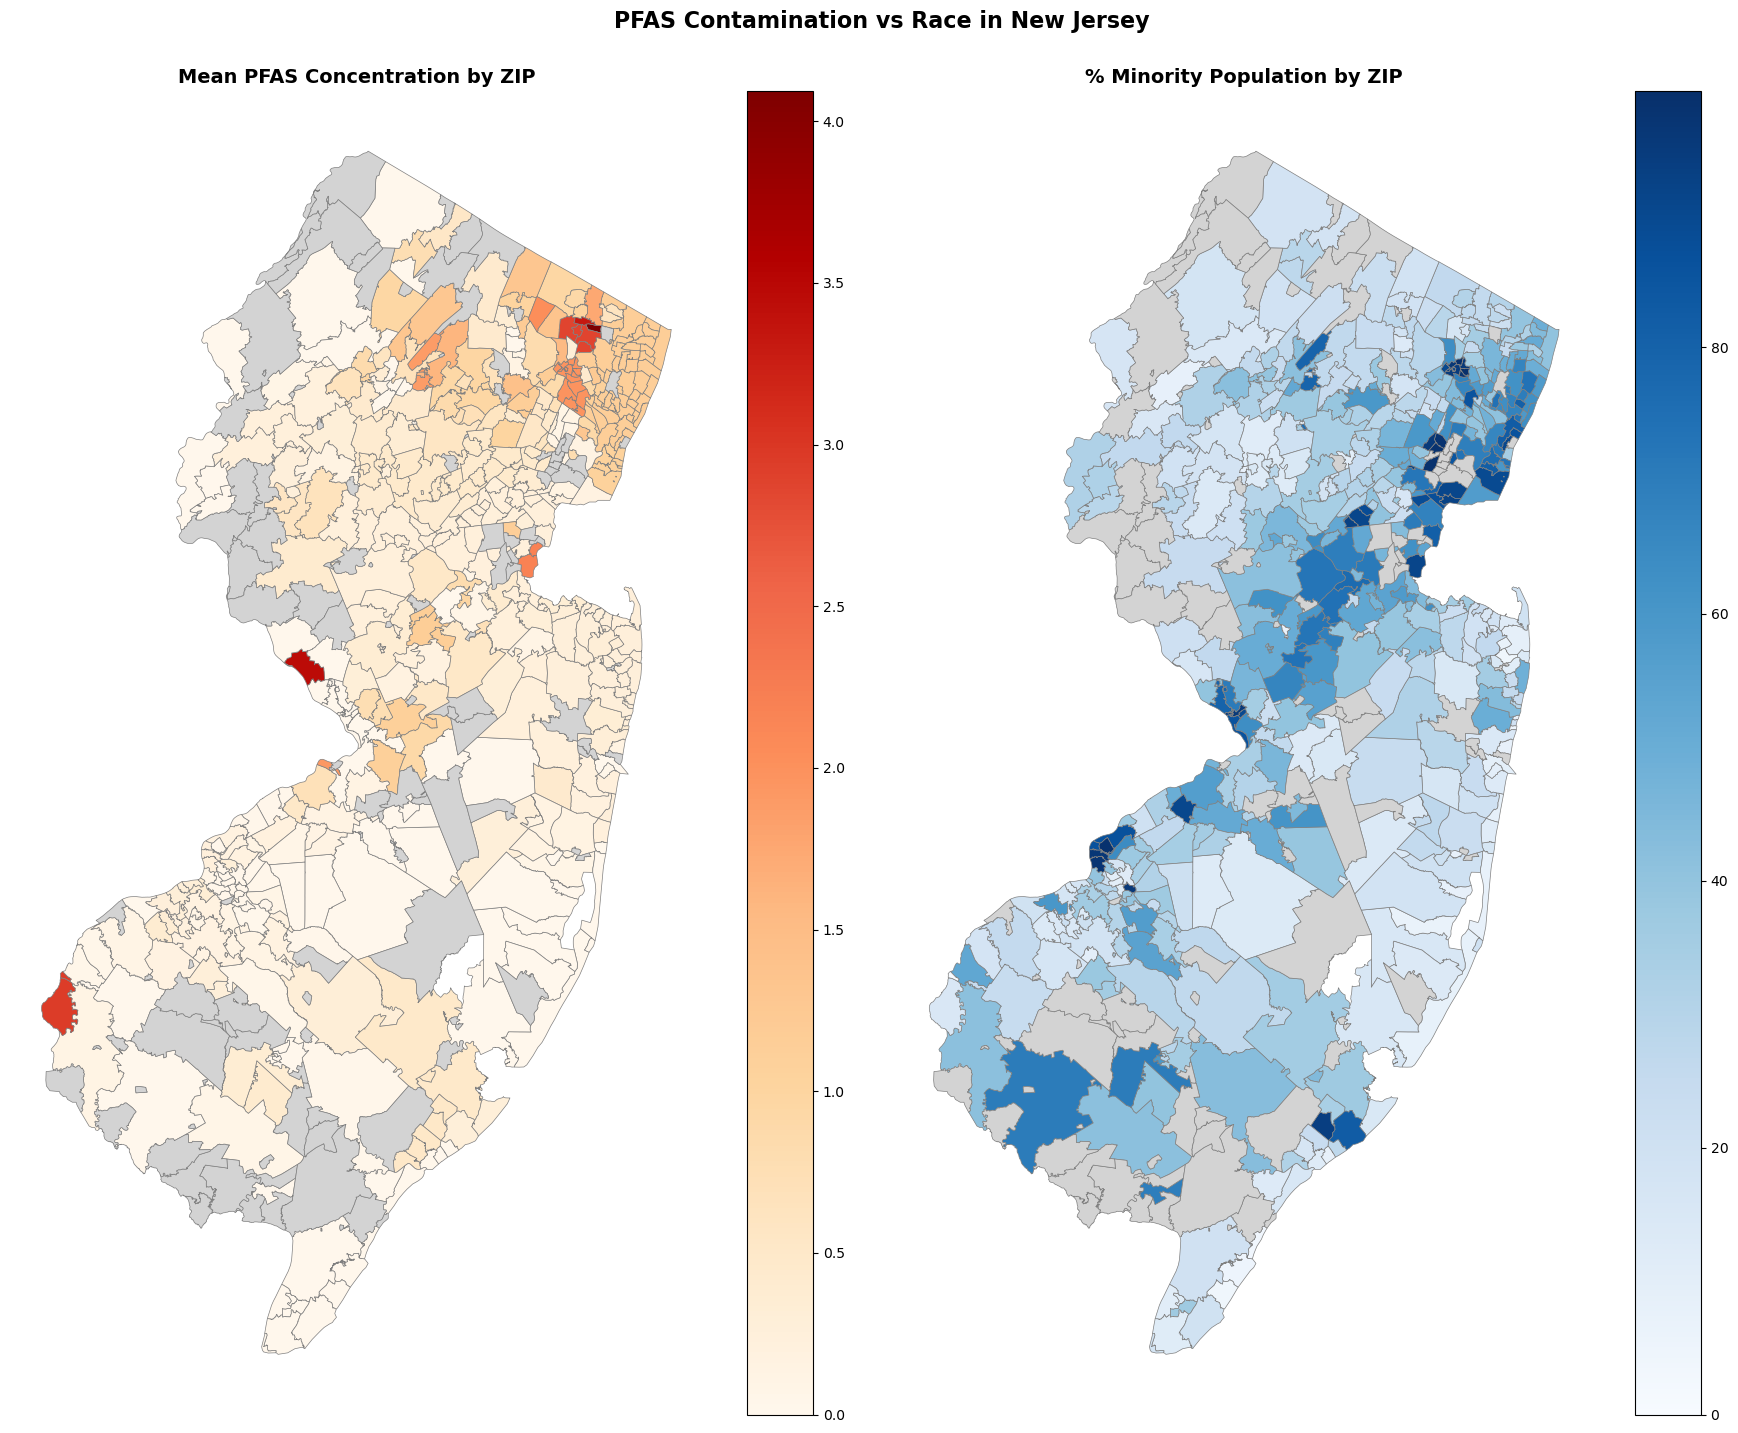

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Left map — PFAS levels
map_df.plot(
    column       = 'mean_pfas',
    cmap         = 'OrRd',
    linewidth    = 0.5,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[0]
)

# Fix 1: use axes[0] not ax
# Fix 2: check legend exists before setting title
legend = axes[0].get_legend()
if legend is not None:
    legend.set_title('PFAS (µg/L)', prop={'size': 10})

axes[0].set_title('Mean PFAS Concentration by ZIP', fontsize=14, fontweight='bold')
axes[0].set_axis_off()

# Right map — % Minority population
map_df.plot(
    column       = 'pct_minority',
    cmap         = 'Blues',
    linewidth    = 0.5,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[1]
)

legend = axes[1].get_legend()
if legend is not None:
    legend.set_title('% Minority', prop={'size': 10})

axes[1].set_title('% Minority Population by ZIP', fontsize=14, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('PFAS Contamination vs Race in New Jersey',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/nj_pfas_vs_race_map.png', dpi=300, bbox_inches='tight')
plt.show()